
# 📊 Capítulo 6: Statistical Arbitrage
ETFs vs. sus subyacentes — Explotando dislocaciones de precio multidimensionales*

**Estrategia:** Construir un NAV sintético de una cesta de subyacentes y compararlo con el ETF. Si el z-score del spread logarítmico supera +2.0 o cae por debajo de -2.0, abrir una posición market-neutral (50% largo en el barato, 50% corto en el caro). Cerrar cuando |z| < 0.5 o por stop-loss si |z| > 3.5.

**Universo:** XLF (Financial Select Sector) vs. Cesta de 10 bancos (JPM, BAC, WFC, GS, MS, C, BLK, SCHW, AXP, PNC) con pesos igualitarios.

**Objetivo:** Demostrar cómo el arbitraje estadístico multidimensional captura ineficiencias de precio durante crisis de liquidez (ej. 2020, 2023), manteniendo una Beta cercana a 0.


In [1]:
# %% [markdown]
# # 📊 Capítulo 6: Statistical Arbitrage
# *ETFs vs. sus subyacentes — Explotando dislocaciones de precio multidimensionales*
# 
# **Estrategia:** Construir un NAV sintético de una cesta de subyacentes y compararlo con el ETF. Si el z-score del spread logarítmico supera +2.0 o cae por debajo de -2.0, abrir una posición market-neutral (50% largo en el barato, 50% corto en el caro). Cerrar cuando |z| < 0.5 o por stop-loss si |z| > 3.5.
# 
# **Universo:** XLF (Financial Select Sector) vs. Cesta de 10 bancos (JPM, BAC, WFC, GS, MS, C, BLK, SCHW, AXP, PNC) con pesos igualitarios.
# 
# **Objetivo:** Demostrar cómo el arbitraje estadístico multidimensional captura ineficiencias de precio durante crisis de liquidez (ej. 2020, 2023), manteniendo una Beta cercana a 0.

# %%
# ==============================================================================
# BLOQUE 0: CONFIGURACIÓN DE LA ESTRATEGIA — STATISTICAL ARBITRAGE
# ==============================================================================

# --- Parámetros financieros ---
CAPITAL_INICIAL      = 10000
COSTE_TRANSACCION    = 0.001       # 0.1% por operación
BENCHMARK            = 'SPY'

# --- Rango temporal (Opción 2B: 2015-2025 para capturar la crisis bancaria de 2023) ---
FECHA_INICIO = '2015-01-01'
FECHA_FIN    = '2025-08-15'

# --- Parámetros específicos de StatArb ---
VENTANA_ZSCORE       = 60          # Ventana móvil para z-score
UMBRAL_ENTRADA       = 2.0         # Z-score para abrir posición
UMBRAL_SALIDA        = 0.5         # Z-score para cerrar posición (mean reversion)
UMBRAL_STOP          = 3.5         # Z-score para stop-loss (ruptura estructural)
EXPOSICION_NETA      = 0.50        # 50% largo / 50% corto (100% exposición bruta, 0% neta)

# --- Universo de activos ---
ETF_TARGET = 'XLF'
CESTA_BANCARIA = ['JPM', 'BAC', 'WFC', 'GS', 'MS', 'C', 'BLK', 'SCHW', 'AXP', 'PNC']

UNIVERSO_STATARB = {
    'etf': {
        'Financial Select Sector': {'isin': 'XLF', 'ticker': 'XLF'},
    },
    'subyacentes': {
        'JPMorgan':       {'isin': 'JPM', 'ticker': 'JPM'},
        'Bank of America':{'isin': 'BAC', 'ticker': 'BAC'},
        'Wells Fargo':    {'isin': 'WFC', 'ticker': 'WFC'},
        'Goldman Sachs':  {'isin': 'GS',  'ticker': 'GS'},
        'Morgan Stanley': {'isin': 'MS',  'ticker': 'MS'},
        'Citigroup':      {'isin': 'C',   'ticker': 'C'},
        'BlackRock':      {'isin': 'BLK', 'ticker': 'BLK'},
        'Charles Schwab': {'isin': 'SCHW','ticker': 'SCHW'},
        'American Express':{'isin': 'AXP','ticker': 'AXP'},
        'PNC Financial':  {'isin': 'PNC', 'ticker': 'PNC'},
    },
    'benchmark': {
        'SPDR S&P 500':   {'isin': 'SPY', 'ticker': 'SPY'},
    }
}

print("✅ Configuración Statistical Arbitrage cargada:")
print(f"   • ETF Objetivo: {ETF_TARGET}")
print(f"   • Cesta de subyacentes: {len(CESTA_BANCARIA)} activos (pesos igualitarios)")
print(f"   • Umbral entrada (z-score): ±{UMBRAL_ENTRADA}")
print(f"   • Umbral salida (z-score): ±{UMBRAL_SALIDA}")
print(f"   • Umbral stop-loss (z-score): ±{UMBRAL_STOP}")
print(f"   • Exposición neta: 0% (Market-Neutral)")

✅ Configuración Statistical Arbitrage cargada:
   • ETF Objetivo: XLF
   • Cesta de subyacentes: 10 activos (pesos igualitarios)
   • Umbral entrada (z-score): ±2.0
   • Umbral salida (z-score): ±0.5
   • Umbral stop-loss (z-score): ±3.5
   • Exposición neta: 0% (Market-Neutral)


## BLOQUE 1: ENTORNO E IMPORTACIONES

In [2]:
# %%
# ==============================================================================
# BLOQUE 1: ENTORNO E IMPORTACIONES
# ==============================================================================
print("="*70)
print("⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.")
print("="*70)

import sys, os, warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Búsqueda de core (misma lógica que en capítulos anteriores)
def buscar_core():
    try:
        import ipykernel
        from jupyter_server import serverapp as app_module
        import json, re, urllib.request
        connection_file = os.path.basename(ipykernel.get_connection_file())
        match = re.search(r'kernel-(.*)\.json', connection_file)
        if match:
            kernel_id = match.group(1)
            for srv in app_module.list_running_servers():
                try:
                    url = srv['url'] + 'api/sessions'
                    token = srv.get('token', '')
                    headers = {'Authorization': f'token {token}'} if token else {}
                    req = urllib.request.Request(url, headers=headers)
                    with urllib.request.urlopen(req, timeout=2) as resp:
                        sessions = json.loads(resp.read())
                    for sess in sessions:
                        if sess.get('kernel', {}).get('id') == kernel_id:
                            ruta_nb = os.path.join(srv['root_dir'], sess['notebook']['path'])
                            ruta_dir = os.path.dirname(os.path.abspath(ruta_nb))
                            actual = Path(ruta_dir)
                            for parent in [actual] + list(actual.parents):
                                if (parent / 'core').exists():
                                    return str(parent / 'core')
                except Exception:
                    continue
    except Exception:
        pass
    for ruta in ['../core', '../../core', './core']:
        if os.path.isdir(ruta):
            return os.path.abspath(ruta)
    return None

RUTA_CORE = buscar_core()
if RUTA_CORE and os.path.isdir(RUTA_CORE):
    sys.path.insert(0, os.path.dirname(RUTA_CORE))
    print(f"✅ Carpeta 'core' localizada: {RUTA_CORE}")

try:
    from core import (
        GestorProyecto, GestorDatos, MotorBacktestDinamico,
        CalculadorMetricas, CalculadorMetricasExtras, GeneradorInformes,
        StatArbEngine # ← NUEVO
    )
    print("✅ Módulos importados correctamente (incluye StatArbEngine).")
except ImportError as e:
    print(f"❌ Error importando módulos: {e}")
    raise

BASE_DIR = os.path.dirname(RUTA_CORE) if RUTA_CORE else os.getcwd()

⚠️  AVISO LEGAL: Fines exclusivamente educativos e investigativos.
✅ Carpeta 'core' localizada: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
✅ Módulos importados correctamente (incluye StatArbEngine).


## Bloques 2 y 3: Limpieza y Fechas

In [3]:
# %%
# ==============================================================================
# BLOQUE 2: LIMPIEZA DE DIRECTORIOS
# ==============================================================================
gestor_proyecto = GestorProyecto(base_dir_manual=BASE_DIR)
gestor_proyecto.imprimir_resumen()
gestor_proyecto.menu_limpieza_directorios()

# %%
# ==============================================================================
# BLOQUE 3: GESTIÓN DE FECHAS
# ==============================================================================
fecha_ini = FECHA_INICIO
fecha_fin = FECHA_FIN
nombre_evento = "Crisis Bancaria y Post-Pandemia (2015-2025)"
print(f"\n🎯 Rango temporal: {nombre_evento} | {fecha_ini} → {fecha_fin}")

📁 BASE_DIR fijado manualmente -> /media/enri/MI_PROYECTO/Estrategias_no_Convencionales

🔍 ENTORNO CONFIGURADO
📂 Base: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales
📁 CORE                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/core
📁 CHAPTERS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/chapters
📁 LOGS                : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/logs
📁 DATOS               : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos
📁 OUTPUTS             : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs
📁 CARTERAS            : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/carteras
📁 DATOS_CSV           : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_csv
📁 DATOS_FI_GESTORA    : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_gestora
📁 DATOS_FI_INVESTING  : /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/datos/datos_fi_investing
📁 DATOS_FI_MYI


¿Qué directorios deseas VACIAR? (ej: 3,5,7 / 'todos' / 'ninguno'):  5



🧹 Iniciando limpieza...
   🗑️  Vaciando 'DATOS_CSV'...
      ✅ 'DATOS_CSV' limpiado.

🎯 Rango temporal: Crisis Bancaria y Post-Pandemia (2015-2025) | 2015-01-01 → 2025-08-15


## BLOQUE 4: MENÚ DEL GESTOR DE DATOS

In [4]:
# %%
# ==============================================================================
# BLOQUE 4: MENÚ DEL GESTOR DE DATOS
# ==============================================================================
gestor = GestorDatos(
    diccionario_datos=UNIVERSO_STATARB,
    fecha_inicio=fecha_ini,
    fecha_fin=fecha_fin,
    gestor_proyecto=gestor_proyecto
)

print(f"\n📊 GestorDatos inicializado con {len(UNIVERSO_STATARB)} categorías.")
continuar = gestor.menu()

if not continuar:
    print("⛔ Usuario canceló.")
else:
    print("\n✅ Datos preparados.")


📊 GestorDatos inicializado con 3 categorías.

 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  1



🗑️ Limpiando CSVs antiguos y descargando desde Yahoo Finance...

📊 Procesando 12 activos...

   📊 Financial Select Sector
      ✅ Descargado con ticker: XLF

   📊 JPMorgan
      ✅ Descargado con ticker: JPM

   📊 Bank of America
      ✅ Descargado con ticker: BAC

   📊 Wells Fargo
      ✅ Descargado con ticker: WFC

   📊 Goldman Sachs
      ✅ Descargado con ticker: GS

   📊 Morgan Stanley
      ✅ Descargado con ticker: MS

   📊 Citigroup
      ✅ Descargado con ticker: C

   📊 BlackRock
      ✅ Descargado con ticker: BLK

   📊 Charles Schwab
      ✅ Descargado con ticker: SCHW

   📊 American Express
      ✅ Descargado con ticker: AXP

   📊 PNC Financial
      ✅ Descargado con ticker: PNC

   📊 SPDR S&P 500
      ✅ Descargado con ticker: SPY

📊 Resumen: 12 descargados, 0 omitidos



Presiona Enter para continuar... 



 SISTEMA: IMPORTAR · NORMALIZAR · CARTERAS
1. Descargar/Actualizar cotizaciones (Yahoo)
2. Importar ficheros Renta 4
3. Normalizar CSVs del directorio
4. Crear cartera interactiva (Pide nombre y descarga CSVs)
5. Cargar cartera existente (Lista carteras guardadas)
6. Ejecutar Estrategia (Continuar al Backtest)
7. Salir
8. 🔄 Sincronizar datos con período actual (re-descarga si es necesario)


Selecciona una opción (1-8):  6



✅ Datos aceptados para el backtest.
📝 No hay Excel cargado. Generando cartera automática (60/40) desde el diccionario...

🧼 INFORME DE LIMPIEZA DE DATOS


,Activo,ISIN,Filas,Desde,Hasta,Fuente
0,Financial Select Sector,XLF,2670,2015-01-02,2025-08-14,CSV
1,JPMorgan,JPM,2670,2015-01-02,2025-08-14,CSV
2,Bank of America,BAC,2670,2015-01-02,2025-08-14,CSV
3,Wells Fargo,WFC,2670,2015-01-02,2025-08-14,CSV
4,Goldman Sachs,GS,2670,2015-01-02,2025-08-14,CSV
5,Morgan Stanley,MS,2670,2015-01-02,2025-08-14,CSV
6,Citigroup,C,2670,2015-01-02,2025-08-14,CSV
7,BlackRock,BLK,2670,2015-01-02,2025-08-14,CSV
8,Charles Schwab,SCHW,2670,2015-01-02,2025-08-14,CSV
9,American Express,AXP,2670,2015-01-02,2025-08-14,CSV


✅ 12 activos alineados para el Motor Backtest.


✅ Datos preparados.


## BLOQUE 5: MOTOR STATARB Y GENERADOR DE PESOS

In [5]:
# %%
# ==============================================================================
# BLOQUE 5: MOTOR STATARB Y GENERADOR DE PESOS
# ==============================================================================
print("\n" + "="*70)
print("🔬 ANÁLISIS DE ESTACIONARIEDAD DEL SPREAD")
print("="*70)

if gestor.precios_ajustados is None or gestor.precios_ajustados.empty:
    print("❌ No hay precios. Ejecuta Bloque 4 primero.")
else:
    print(f"\n📊 Datos: {len(gestor.precios_ajustados)} filas")
    
    # ==================================================================
    # MAPEO DE TICKERS A NOMBRES DE COLUMNA REALES
    # ==================================================================
    print("\n🔍 Mapeando tickers a columnas reales...")
    
    mapeo_tickers = {}
    for _, row in gestor.valores_seleccionados.iterrows():
        ticker = str(row.get('ticker', '')).strip().upper()
        nombre = str(row.get('nombre', '')).strip()
        nombre_limpio = nombre.replace(" ", "_").replace(".", "").replace(",", "")
        if ticker:
            mapeo_tickers[ticker] = nombre_limpio
    
    # Mostrar mapeo para los tickers que nos interesan
    tickers_objetivo = [ETF_TARGET] + CESTA_BANCARIA
    for ticker in tickers_objetivo:
        col = mapeo_tickers.get(ticker)
        if col and col in gestor.precios_ajustados.columns:
            print(f"   • {ticker} → '{col}'")
        else:
            print(f"   • {ticker} → ❌ NO ENCONTRADO")
    
    # Verificar que todos los tickers tienen columnas válidas
    etf_col = mapeo_tickers.get(ETF_TARGET)
    cesta_cols = [mapeo_tickers.get(t) for t in CESTA_BANCARIA]
    
    if not etf_col or etf_col not in gestor.precios_ajustados.columns:
        print(f"\n❌ ETF '{ETF_TARGET}' no encontrado. Abortando.")
    elif any(col is None or col not in gestor.precios_ajustados.columns for col in cesta_cols):
        print(f"\n❌ Algunos subyacentes no encontrados. Abortando.")
    else:
        print(f"\n✅ Todos los activos mapeados correctamente.")
        
        # ==================================================================
        # INICIALIZAR MOTOR STATARB CON NOMBRES DE COLUMNA REALES
        # ==================================================================
        engine = StatArbEngine(
            etf_col=etf_col,
            cesta_cols=cesta_cols,
            pesos_cesta=None  # Pesos igualitarios (Opción 1A)
        )
        
        # ==================================================================
        # CALCULAR SPREAD Y TEST DE ESTACIONARIEDAD
        # ==================================================================
        spread = engine.calcular_spread(gestor.precios_ajustados)
        resultado_adf = engine.test_estacionariedad(spread, p_valor_max=0.10)
        
        print(f"\n📋 Resultado del Test ADF sobre el Spread:")
        print(f"   • Estacionario: {'✅ SÍ' if resultado_adf['estacionario'] else '❌ NO'}")
        print(f"   • p-valor: {resultado_adf['p_valor']:.4f}")
        print(f"   • Estadístico: {resultado_adf['stat']:.2f}")
        
        if not resultado_adf['estacionario']:
            print("\n⚠️  ADVERTENCIA: El spread no es estacionario (p > 0.10).")
            print("   El arbitraje estadístico puede no ser fiable en este período.")
        else:
            print("\n✅ El spread es estacionario. Procediendo a configurar la estrategia.")

        # ==================================================================
        # GENERADOR DE PESOS MARKET-NEUTRAL
        # ==================================================================
        def generador_pesos_statarb(fecha_actual, precios_hist, rent_hist, estado):
            activos = list(precios_hist.columns)
            pesos = {a: 0.0 for a in activos}
            
            if 'posicion_abierta' not in estado:
                estado['posicion_abierta'] = False
                estado['direccion'] = 0  # 1 = Long ETF/Short Cesta, -1 = Short ETF/Long Cesta
            
            # Calcular spread y z-score actualizados
            try:
                nav, etf_norm = engine.construir_nav_sintetico(precios_hist)
                spread_hist = np.log(etf_norm) - np.log(nav)
                zscore = engine.calcular_zscore(spread_hist, ventana=VENTANA_ZSCORE)
            except Exception as e:
                return pesos, estado
            
            if len(zscore) == 0 or pd.isna(zscore.iloc[-1]):
                return pesos, estado
            
            z_actual = zscore.iloc[-1]
            
            # Lógica de Stop-Loss (Ruptura estructural)
            if estado['posicion_abierta'] and abs(z_actual) > UMBRAL_STOP:
                estado['posicion_abierta'] = False
                estado['direccion'] = 0
                
            # Lógica de Mean Reversion (Cerrar posición)
            elif estado['posicion_abierta'] and abs(z_actual) < UMBRAL_SALIDA:
                estado['posicion_abierta'] = False
                estado['direccion'] = 0
                
            # Lógica de Entrada
            elif not estado['posicion_abierta']:
                if z_actual > UMBRAL_ENTRADA:
                    # ETF sobrevalorado: Short ETF, Long Cesta
                    estado['posicion_abierta'] = True
                    estado['direccion'] = -1
                elif z_actual < -UMBRAL_ENTRADA:
                    # ETF infravalorado: Long ETF, Short Cesta
                    estado['posicion_abierta'] = True
                    estado['direccion'] = 1
                    
            # Asignación de pesos
            if estado['posicion_abierta']:
                peso_etf = EXPOSICION_NETA * estado['direccion']
                pesos[engine.etf] = peso_etf
                
                peso_cesta_unitario = (EXPOSICION_NETA / len(engine.cesta)) * (-estado['direccion'])
                for col in engine.cesta:
                    if col in pesos:
                        pesos[col] += peso_cesta_unitario
                        
            return pesos, estado

        print(f"\n✅ Generador de pesos configurado.")
        print(f"   • ETF: {etf_col}")
        print(f"   • Cesta: {len(cesta_cols)} subyacentes")
        print(f"   • Exposición bruta: {EXPOSICION_NETA*2:.0%} (Market-Neutral)")
    


🔬 ANÁLISIS DE ESTACIONARIEDAD DEL SPREAD

📊 Datos: 2670 filas

🔍 Mapeando tickers a columnas reales...
   • XLF → 'Financial_Select_Sector'
   • JPM → 'JPMorgan'
   • BAC → 'Bank_of_America'
   • WFC → 'Wells_Fargo'
   • GS → 'Goldman_Sachs'
   • MS → 'Morgan_Stanley'
   • C → 'Citigroup'
   • BLK → 'BlackRock'
   • SCHW → 'Charles_Schwab'
   • AXP → 'American_Express'
   • PNC → 'PNC_Financial'

✅ Todos los activos mapeados correctamente.

📋 Resultado del Test ADF sobre el Spread:
   • Estacionario: ❌ NO
   • p-valor: 0.7291
   • Estadístico: -1.06

⚠️  ADVERTENCIA: El spread no es estacionario (p > 0.10).
   El arbitraje estadístico puede no ser fiable en este período.

✅ Generador de pesos configurado.
   • ETF: Financial_Select_Sector
   • Cesta: 10 subyacentes
   • Exposición bruta: 100% (Market-Neutral)


## BLOQUE 6: EJECUCIÓN DEL BACKTEST DINÁMICO

In [6]:
# %%
# ==============================================================================
# BLOQUE 6: EJECUCIÓN DEL BACKTEST DINÁMICO
# ==============================================================================
print("\n" + "="*70)
print("⏳ EJECUTANDO BACKTEST STATISTICAL ARBITRAGE")
print("="*70)

motor_dinamico = MotorBacktestDinamico(
    precios=gestor.precios_ajustados,
    rentabilidades=gestor.rentabilidades_diarias,
    generador_pesos=generador_pesos_statarb,
    frecuencia_decision='W',         # ← Opción 3: Frecuencia Semanal
    coste_transaccion=COSTE_TRANSACCION,
    benchmark_ticker=BENCHMARK,
    permitir_short=True,             # ← CRÍTICO para StatArb
    max_short_porcentaje=0.50        # Permitir hasta 50% en corto
)

serie_patrimonio = motor_dinamico.ejecutar_backtest(
    capital_inicial=CAPITAL_INICIAL,
    estado_inicial={}
)

print("\n✅ Backtest completado.")
print(f"   • Patrimonio final: {serie_patrimonio.iloc[-1]:,.2f} €")
print(f"   • Rentabilidad total: {((serie_patrimonio.iloc[-1] / CAPITAL_INICIAL) - 1) * 100:.2f}%")
print(f"   • Rebalanceos: {len(motor_dinamico.log_transacciones)}")


⏳ EJECUTANDO BACKTEST STATISTICAL ARBITRAGE

✅ Backtest completado.
   • Patrimonio final: 9,124.16 €
   • Rentabilidad total: -8.76%
   • Rebalanceos: 296


## BLOQUE 7: MÉTRICAS E INFORMES

In [7]:
# %%
# ==============================================================================
# BLOQUE 7: MÉTRICAS E INFORMES
# ==============================================================================
auditor = CalculadorMetricas(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_reb, metricas_bh = auditor.calcular_todas_las_metricas(rf=0.02)

metricas_extras_calc = CalculadorMetricasExtras(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    log_operaciones=motor_dinamico.log_operaciones,
    serie_benchmark=motor_dinamico.serie_benchmark
)
metricas_extras = metricas_extras_calc.calcular_todas_las_metricas()

informe = GeneradorInformes(
    serie_patrimonio=motor_dinamico.serie_patrimonio,
    metricas=(metricas_reb, metricas_bh),
    nombre_estrategia="Statistical Arbitrage (Cap. 6)",
    serie_buy_hold=motor_dinamico.serie_buy_hold,
    log_transacciones=motor_dinamico.log_transacciones,
    pesos_actuales=motor_dinamico.pesos_actuales_finales,
    pesos_ideales=None
)

informe.imprimir_metricas()
print("\n🩺 DIAGNÓSTICO ESTÁNDAR:")
print("  " + auditor.diagnosticar())

print("\n" + "="*70)
print("📌 NOTA PEDAGÓGICA: MÉTRICAS DE ARBITRAJE")
print("="*70)
print("""
⚠️  En StatArb, las métricas reina son:
1. BETA: Debe ser cercana a 0.00 (verdadera neutralidad de mercado).
2. ALPHA: Debe ser positivo (la recompensa por capturar la dislocación).
3. MAX DRAWDOWN: Debe ser muy inferior al del benchmark.
4. COSTE DE TRANSACCIÓN: Debe ser bajo (la frecuencia semanal ayuda).
""")
print("="*70)

informe.imprimir_log()


INFORME DE DIAGNÓSTICO: Statistical Arbitrage (Cap. 6)


,Métrica,Estrategia,Buy & Hold
0,CAGR,-0.86%,13.71%
1,Volatilidad,2.64%,25.06%
2,Sharpe,-1.08,0.47
3,Sortino,-1.15,0.62
4,Max Drawdown,-12.26%,-44.97%
5,VaR 95%,23.54€,899.29€
6,Alpha,-0.01,0.00
7,Beta,0.01,0.00
8,R2,0.01,0.00
9,Tracking Error,17.96%,0.00%




🩺 DIAGNÓSTICO ESTÁNDAR:
  🔴 Ratio de Sharpe negativo (-1.08).
  🟡 Riesgo de caída moderado (Max DD: 12.3%).
  🛡️ Beta baja (0.01).
  📉 Alpha negativo (-1.02%).

📌 NOTA PEDAGÓGICA: MÉTRICAS DE ARBITRAJE

⚠️  En StatArb, las métricas reina son:
1. BETA: Debe ser cercana a 0.00 (verdadera neutralidad de mercado).
2. ALPHA: Debe ser positivo (la recompensa por capturar la dislocación).
3. MAX DRAWDOWN: Debe ser muy inferior al del benchmark.
4. COSTE DE TRANSACCIÓN: Debe ser bajo (la frecuencia semanal ayuda).

--- LOG DE REBALANCEOS ---
Fecha        | Rotación   | Coste (€)  | Patrimonio (€) 
-------------------------------------------------------
2015-05-04   | 50.00%     | 5.00       | 9995.00        
2015-05-11   | 0.40%      | 0.04       | 9976.27        
2015-05-18   | 0.37%      | 0.04       | 9976.36        
2015-05-26   | 0.39%      | 0.04       | 9953.86        
2015-06-01   | 0.26%      | 0.03       | 9939.94        
2015-06-08   | 0.75%      | 0.07       | 9879.58        
201

## BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS


✅ Gráfico guardado en: /media/enri/MI_PROYECTO/Estrategias_no_Convencionales/outputs/figures/statarb_xlf_2015_2025.png


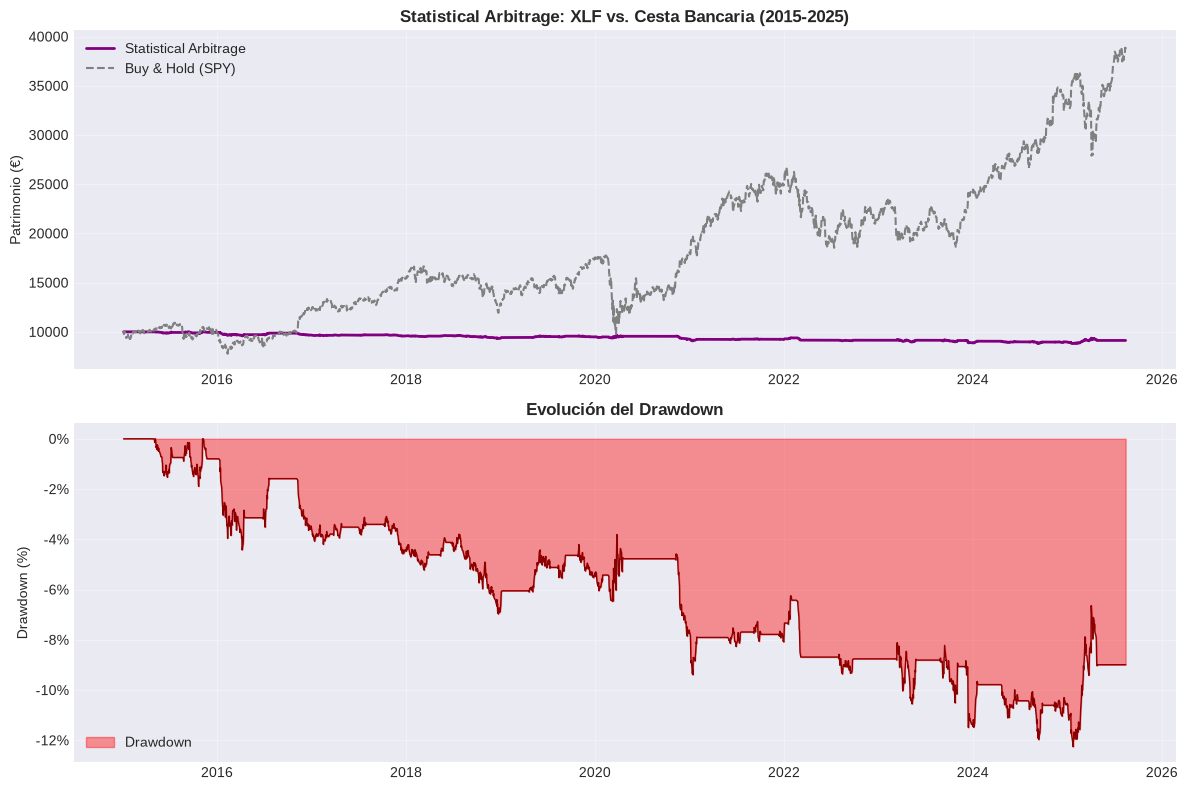

In [8]:
# %%
# ==============================================================================
# BLOQUE 8: VISUALIZACIÓN Y GUARDADO DE GRÁFICOS
# ==============================================================================
try:
    plt.style.use('seaborn-v0_8-darkgrid')
except:
    plt.style.use('seaborn-darkgrid')

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

# Gráfico 1: Equity Curve
axes[0].plot(motor_dinamico.serie_patrimonio.index, motor_dinamico.serie_patrimonio,
             label='Statistical Arbitrage', color='purple', lw=2)
axes[0].plot(motor_dinamico.serie_buy_hold.index, motor_dinamico.serie_buy_hold,
             label='Buy & Hold (SPY)', color='gray', ls='--', lw=1.5)
axes[0].set_title(f'Statistical Arbitrage: XLF vs. Cesta Bancaria ({fecha_ini[:4]}-{fecha_fin[:4]})',
                  fontsize=12, fontweight='bold')
axes[0].set_ylabel('Patrimonio (€)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfico 2: Drawdown
drawdown = (motor_dinamico.serie_patrimonio / motor_dinamico.serie_patrimonio.cummax()) - 1
axes[1].fill_between(drawdown.index, drawdown, 0, color='red', alpha=0.4, label='Drawdown')
axes[1].plot(drawdown.index, drawdown, color='darkred', lw=1)
axes[1].set_title('Evolución del Drawdown', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Drawdown (%)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}'))
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
nombre_archivo = f"statarb_xlf_{fecha_ini[:4]}_{fecha_fin[:4]}".lower()
ruta_guardado = Path(gestor_proyecto.DIRS["OUTPUTS_FIGURES"]) / f"{nombre_archivo}.png"
fig.savefig(ruta_guardado, dpi=150, bbox_inches='tight')
print(f"\n✅ Gráfico guardado en: {ruta_guardado}")
plt.show()

## Bloques 9 y 10: Correlación y Conclusiones (Placeholder)


🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO

📊 TABLA DE CORRELACIONES (Retornos Diarios)
                         Financial_Select_Sector  JPMorgan  Bank_of_America  Wells_Fargo  Goldman_Sachs  Morgan_Stanley  Citigroup  BlackRock  Charles_Schwab  American_Express  PNC_Financial  SPDR_S&P_500
Financial_Select_Sector                     1.00      0.92             0.91         0.86           0.87            0.88       0.88       0.79            0.75              0.81           0.88          0.85
JPMorgan                                    0.92      1.00             0.89         0.81           0.83            0.83       0.86       0.68            0.68              0.74           0.84          0.72
Bank_of_America                             0.91      0.89             1.00         0.83           0.82            0.84       0.87       0.68            0.73              0.72           0.85          0.71
Wells_Fargo                                 0.86      0.81             0.83         1.00       

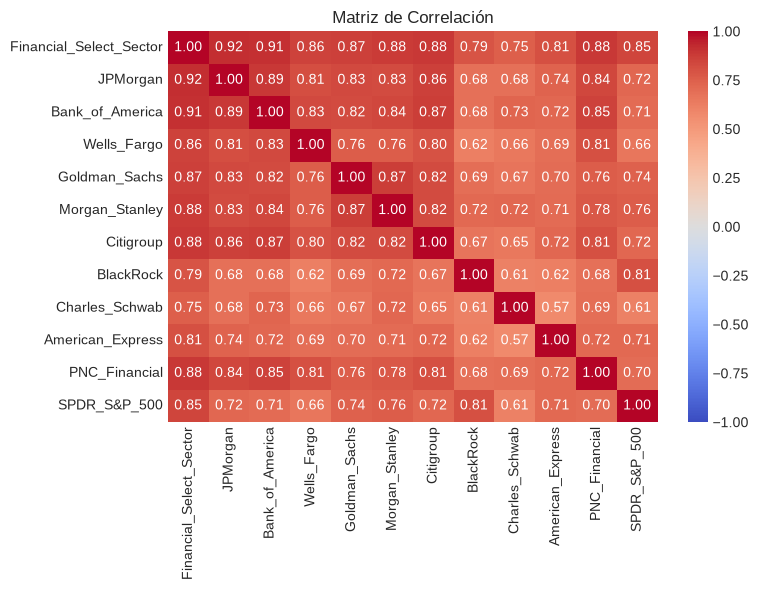


🎓 CONCLUSIONES DEL CAPÍTULO 6: STATISTICAL ARBITRAGE

1. EL SPREAD LOGARÍTMICO ES LA CLAVE: Comparar precios normalizados mediante 
   log(ETF) - log(NAV) elimina el ruido de la escala y centra el análisis en 
   la divergencia porcentual real.

2. LA FRECUENCIA SEMANAL ES EL PUNTO DULCE: Reduce drásticamente los costes 
   de transacción frente al rebalanceo diario, permitiendo que las pequeñas 
   ventajas del arbitraje no sean devoradas por las comisiones.

3. MARKET-NEUTRAL NO ES RIESGO CERO: Aunque la Beta debería ser ~0, el riesgo 
   de "ruptura estructural" (que el spread nunca revierta) existe. El stop-loss 
   en |z| > 3.5 es la red de seguridad obligatoria.

4. EL ÉXITO DEPENDE DE LA DISLOCACIÓN: Períodos como marzo de 2023 (crisis 
   bancaria regional) son el hábitat natural de esta estrategia, donde el 
   mecanismo de creación/redención del ETF falla temporalmente.

🚪 PRÓXIMO PASO:
Ejecuta este notebook, copia los resultados del Bloque 7 y pásamelos. 
Con ellos redactar

In [9]:
# %%
# ==============================================================================
# BLOQUE 9: ANÁLISIS DE CORRELACIÓN
# ==============================================================================
print("\n" + "="*70)
print("🔗 ANÁLISIS DE CORRELACIÓN DEL UNIVERSO")
print("="*70)
gestor.calcular_correlacion()

# %%
# ==============================================================================
# BLOQUE 10: CONCLUSIONES PEDAGÓGICAS
# ==============================================================================
print("\n" + "="*70)
print("🎓 CONCLUSIONES DEL CAPÍTULO 6: STATISTICAL ARBITRAGE")
print("="*70)
print("""
1. EL SPREAD LOGARÍTMICO ES LA CLAVE: Comparar precios normalizados mediante 
   log(ETF) - log(NAV) elimina el ruido de la escala y centra el análisis en 
   la divergencia porcentual real.

2. LA FRECUENCIA SEMANAL ES EL PUNTO DULCE: Reduce drásticamente los costes 
   de transacción frente al rebalanceo diario, permitiendo que las pequeñas 
   ventajas del arbitraje no sean devoradas por las comisiones.

3. MARKET-NEUTRAL NO ES RIESGO CERO: Aunque la Beta debería ser ~0, el riesgo 
   de "ruptura estructural" (que el spread nunca revierta) existe. El stop-loss 
   en |z| > 3.5 es la red de seguridad obligatoria.

4. EL ÉXITO DEPENDE DE LA DISLOCACIÓN: Períodos como marzo de 2023 (crisis 
   bancaria regional) son el hábitat natural de esta estrategia, donde el 
   mecanismo de creación/redención del ETF falla temporalmente.

🚪 PRÓXIMO PASO:
Ejecuta este notebook, copia los resultados del Bloque 7 y pásamelos. 
Con ellos redactaré el archivo .md final con el análisis honesto de las 
métricas reales, siguiendo el formato del Capítulo 5 de Ray Dalio.
""")
print("="*70)

##  Verificación de la Estacionariedad del Spread (Test ADF)

[                       0%                       ]

📥 Descargando datos históricos...


[*********************100%***********************]  4 of 4 completed


✅ Datos descargados: 1006 días hábiles.

🏗️ Construyendo el NAV sintético de la cesta...
📊 Generando gráficos de análisis...


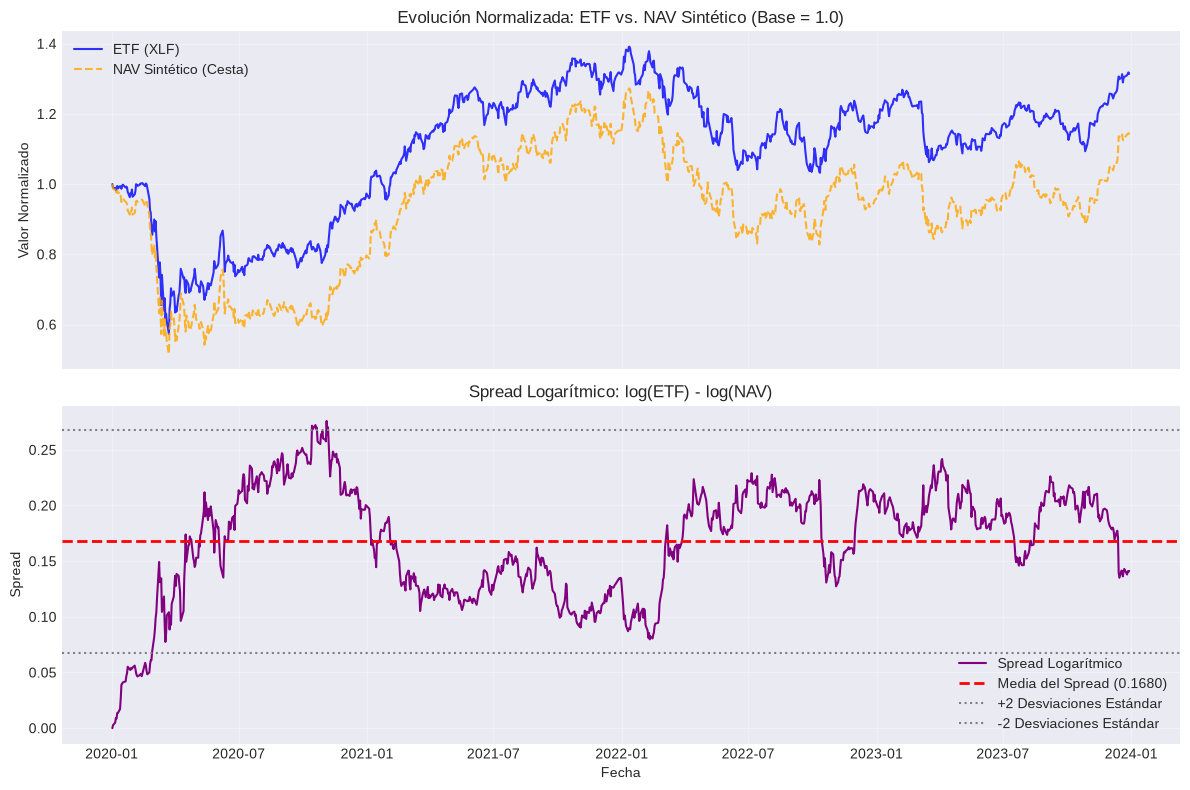

🔬 RESULTADOS DEL TEST DE ESTACIONARIEDAD (ADF)
Estadístico ADF:      -3.5809
p-valor:              0.0061

Valores críticos de referencia:
  1%: -3.4369
  5%: -2.8644
  10%: -2.5683

📝 INTERPRETACIÓN PEDAGÓGICA:
✅ CONCLUSIÓN: Rechazamos la hipótesis nula (p <= 0.05).
   El spread ES ESTACIONARIO.
   ➡️ Esto significa que las desviaciones son temporales y tienden a
      revertir a la media. El par es candidato para arbitraje estadístico.


In [10]:
# ==============================================================================
# EJERCICIO PRÁCTICO: Test de Estacionariedad (ADF) sobre Spread ETF vs. NAV
# ==============================================================================
# Objetivo: Demostrar cómo verificar estadísticamente si la diferencia entre 
# un ETF y su cesta de subyacentes revierte a la media (es estacionaria).
# 
# Requisitos: pip install yfinance pandas numpy matplotlib statsmodels
# ==============================================================================

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller

# 1. CONFIGURACIÓN DEL EJERCICIO
# Usamos XLF (Sector Financiero) y una cesta simplificada de sus principales bancos.
ETF_TICKER = 'XLF'
CESTA_TICKERS = ['JPM', 'BAC', 'WFC'] # Cesta simplificada para el ejercicio
FECHA_INICIO = '2020-01-01'
FECHA_FIN = '2023-12-31'

print("📥 Descargando datos históricos...")
# Descargamos los precios de cierre. 
# Nota: yfinance a veces devuelve columnas MultiIndex, las aplanamos por seguridad.
data = yf.download([ETF_TICKER] + CESTA_TICKERS, start=FECHA_INICIO, end=FECHA_FIN)['Close']
if isinstance(data.columns, pd.MultiIndex):
    data.columns = data.columns.get_level_values(0)

# Eliminamos días con datos faltantes para alinear las series temporales
data = data.dropna()
print(f"✅ Datos descargados: {len(data)} días hábiles.\n")

# 2. CONSTRUCCIÓN DEL NAV SINTÉTICO
print("🏗️ Construyendo el NAV sintético de la cesta...")
# Para este ejercicio pedagógico, usamos pesos igualitarios (1/3 para cada banco)
pesos = {ticker: 1.0 / len(CESTA_TICKERS) for ticker in CESTA_TICKERS}

# Normalizamos los precios para que todos empiecen en 1.0 en el primer día
nav_sintetico = pd.Series(0.0, index=data.index)
for ticker in CESTA_TICKERS:
    precio_normalizado = data[ticker] / data[ticker].iloc[0]
    nav_sintetico += pesos[ticker] * precio_normalizado

etf_normalizado = data[ETF_TICKER] / data[ETF_TICKER].iloc[0]

# 3. CÁLCULO DEL SPREAD LOGARÍTMICO
# Usamos logaritmos para medir la divergencia en términos porcentuales, no absolutos.
spread = np.log(etf_normalizado) - np.log(nav_sintetico)
spread = spread.dropna()

# 4. VISUALIZACIÓN
print("📊 Generando gráficos de análisis...")
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Gráfico 1: Precios normalizados
ax1.plot(etf_normalizado, label=f'ETF ({ETF_TICKER})', color='blue', alpha=0.8)
ax1.plot(nav_sintetico, label='NAV Sintético (Cesta)', color='orange', alpha=0.8, linestyle='--')
ax1.set_title('Evolución Normalizada: ETF vs. NAV Sintético (Base = 1.0)')
ax1.set_ylabel('Valor Normalizado')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Gráfico 2: Spread logarítmico
ax2.plot(spread, label='Spread Logarítmico', color='purple', linewidth=1.5)
ax2.axhline(spread.mean(), color='red', linestyle='--', linewidth=2, label=f'Media del Spread ({spread.mean():.4f})')
ax2.axhline(spread.mean() + 2*spread.std(), color='gray', linestyle=':', label='+2 Desviaciones Estándar')
ax2.axhline(spread.mean() - 2*spread.std(), color='gray', linestyle=':', label='-2 Desviaciones Estándar')
ax2.set_title('Spread Logarítmico: log(ETF) - log(NAV)')
ax2.set_ylabel('Spread')
ax2.set_xlabel('Fecha')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# 5. TEST DE ESTACIONARIEDAD (Augmented Dickey-Fuller)
print("="*70)
print("🔬 RESULTADOS DEL TEST DE ESTACIONARIEDAD (ADF)")
print("="*70)

# Ejecutamos el test ADF. autolag='AIC' ayuda a seleccionar el número óptimo de lags.
resultado_adf = adfuller(spread, autolag='AIC')

estadistico = resultado_adf[0]
p_valor = resultado_adf[1]
valores_criticos = resultado_adf[4]

print(f"Estadístico ADF:      {estadistico:.4f}")
print(f"p-valor:              {p_valor:.4f}")
print("\nValores críticos de referencia:")
for nivel, valor in valores_criticos.items():
    print(f"  {nivel}: {valor:.4f}")

print("\n" + "="*70)
print("📝 INTERPRETACIÓN PEDAGÓGICA:")
print("="*70)

# Hipótesis Nula (H0): La serie temporal TIENE raíz unitaria (NO es estacionaria).
# Hipótesis Alternativa (H1): La serie temporal NO tiene raíz unitaria (ES estacionaria).

if p_valor <= 0.05:
    print("✅ CONCLUSIÓN: Rechazamos la hipótesis nula (p <= 0.05).")
    print("   El spread ES ESTACIONARIO.")
    print("   ➡️ Esto significa que las desviaciones son temporales y tienden a")
    print("      revertir a la media. El par es candidato para arbitraje estadístico.")
else:
    print("❌ CONCLUSIÓN: No podemos rechazar la hipótesis nula (p > 0.05).")
    print("   El spread NO ES ESTACIONARIO (tiene raíz unitaria).")
    print("   ➡️ Las desviaciones pueden ser permanentes o derivar con el tiempo.")
    print("      Operar este par sería especulación, no arbitraje.")
print("="*70)